# Dataset Analysis: `apple/CLaRa_multi_stage`

This notebook analyzes the `apple/CLaRa_multi_stage` dataset used for training the CLaRa model. We'll explore the structure, content, and distributions of various features.

In [6]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load a slice of the dataset
ds_name = "apple/CLaRa_multi_stage"
num_samples = 1000
ds = load_dataset(ds_name, split="train", streaming=True).take(num_samples)
data = list(ds)

print(f"Loaded {len(data)} samples from {ds_name}")
print("Features:", data[0].keys())

Loaded 1000 samples from apple/CLaRa_multi_stage
Features: dict_keys(['question', 'answer', 'docs', 'pos_index'])


In [8]:
df = pd.DataFrame(data)

# Basic stats
df['num_docs'] = df['docs'].apply(len)
df['question_len'] = df['question'].apply(len)
df['answer_len'] = df['answer'].apply(len)
df['avg_doc_len'] = df['docs'].apply(lambda docs: np.mean([len(d) for d in docs]) if docs else 0)

print("--- Dataset Statistics ---")
print(df[['num_docs', 'question_len', 'answer_len', 'avg_doc_len']].describe())

# Check pos_index
pos_index_populated = sum(1 for x in df['pos_index'] if x and len(x) > 0)
print(f"\nExamples with populated pos_index: {pos_index_populated} / {len(df)}")

--- Dataset Statistics ---
       num_docs  question_len  answer_len  avg_doc_len
count    1000.0   1000.000000  1000.00000  1000.000000
mean       20.0     71.638000     8.95500   481.390450
std         0.0     18.323556     6.85054   113.024185
min        20.0     31.000000     2.00000    99.350000
25%        20.0     58.750000     2.00000   403.825000
50%        20.0     68.000000     8.00000   482.125000
75%        20.0     83.000000    14.00000   556.125000
max        20.0    138.000000    56.00000   819.600000

Examples with populated pos_index: 0 / 1000


In [9]:
# Display a few samples
pd.set_option('display.max_colwidth', 100)
print("--- Sample Data ---")
print(df[['question', 'answer', 'num_docs']].head(5))

# Look at one full example
idx = 0
print(f"\n--- Full Example {idx} ---")
print(f"Question: {data[idx]['question']}")
print(f"Answer: {data[idx]['answer']}")
print(f"Number of docs: {len(data[idx]['docs'])}")
print(f"First doc snippet: {data[idx]['docs'][0][:200]}...")

--- Sample Data ---
                                                                                              question  \
0  Are director of film Move (1970 Film) and director of film Méditerranée (1963 Film) from the sam...   
1      Do both films The Falcon (Film) and Valentin The Good have the directors from the same country?   
2                           Which film whose director is younger, Charge It To Me or Danger: Diabolik?   
3                                               What is the date of birth of Mina Gerhardsen's father?   
4                      What nationality is the director of film Wedding Night In Paradise (1950 Film)?   

             answer  num_docs  
0                no        20  
1                no        20  
2  Danger: Diabolik        20  
3      13 June 1946        20  
4         Hungarian        20  

--- Full Example 0 ---
Question: Are director of film Move (1970 Film) and director of film Méditerranée (1963 Film) from the same country?
Answer: no

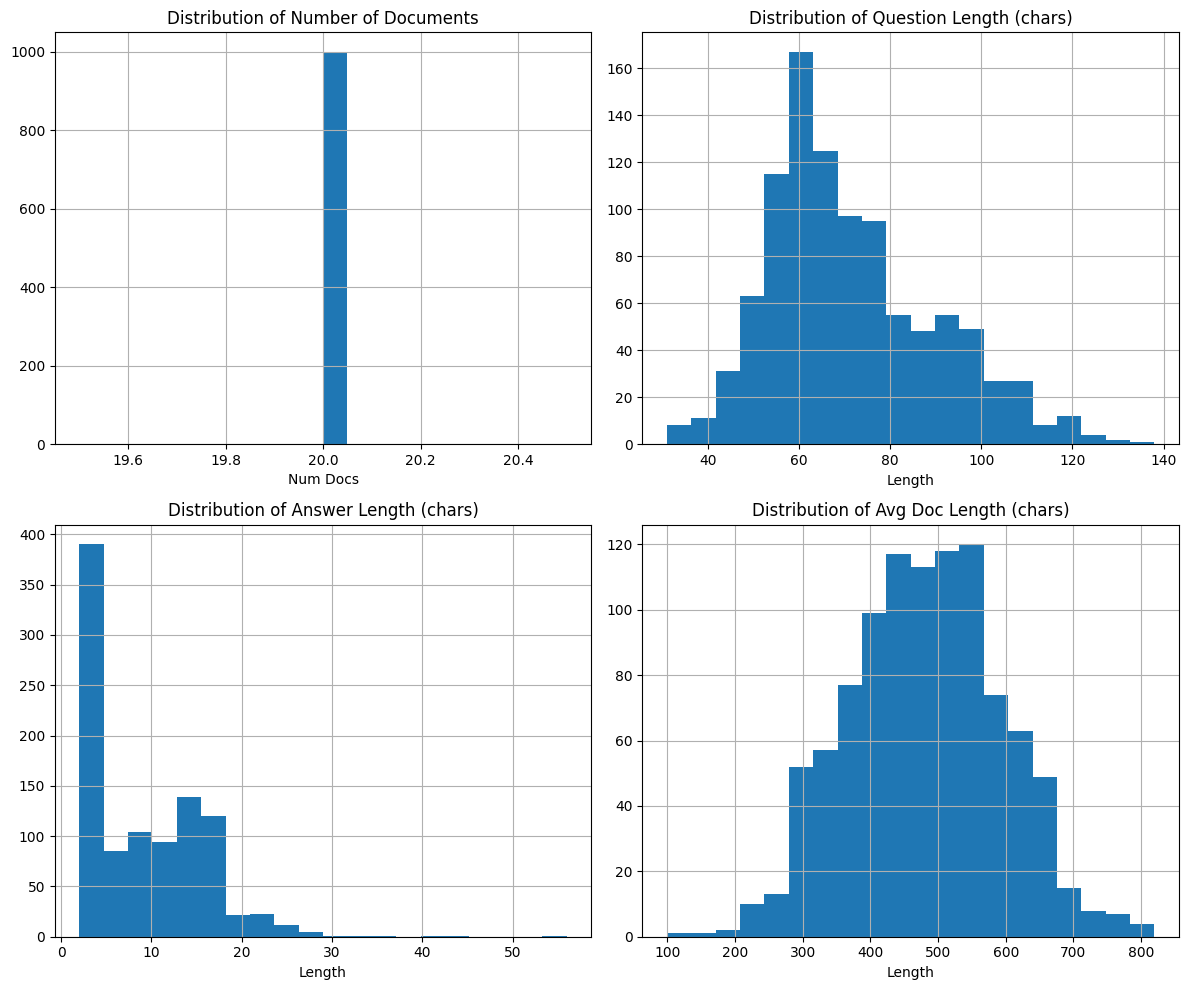

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

df['num_docs'].hist(ax=axes[0, 0], bins=20)
axes[0, 0].set_title('Distribution of Number of Documents')
axes[0, 0].set_xlabel('Num Docs')

df['question_len'].hist(ax=axes[0, 1], bins=20)
axes[0, 1].set_title('Distribution of Question Length (chars)')
axes[0, 1].set_xlabel('Length')

df['answer_len'].hist(ax=axes[1, 0], bins=20)
axes[1, 0].set_title('Distribution of Answer Length (chars)')
axes[1, 0].set_xlabel('Length')

df['avg_doc_len'].hist(ax=axes[1, 1], bins=20)
axes[1, 1].set_title('Distribution of Avg Doc Length (chars)')
axes[1, 1].set_xlabel('Length')

plt.tight_layout()
plt.show()

Total documents across 1000 samples: 20000
Average words per document: 79.17
Max words in a document: 210


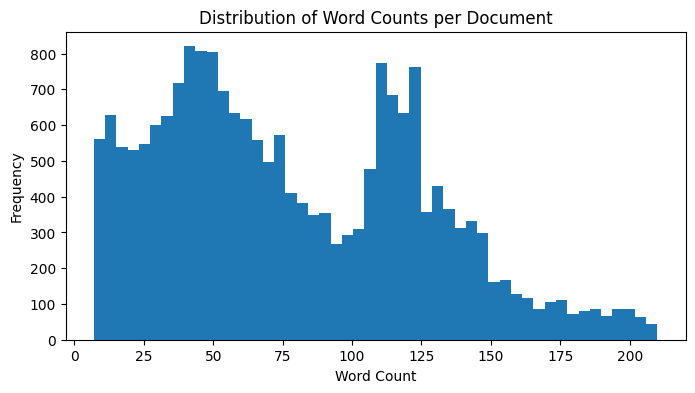

In [11]:
# Analyze document content
all_docs = [doc for docs in df['docs'] for doc in docs]
doc_word_counts = [len(doc.split()) for doc in all_docs]

print(f"Total documents across {len(df)} samples: {len(all_docs)}")
print(f"Average words per document: {np.mean(doc_word_counts):.2f}")
print(f"Max words in a document: {np.max(doc_word_counts)}")

plt.figure(figsize=(8, 4))
plt.hist(doc_word_counts, bins=50)
plt.title('Distribution of Word Counts per Document')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()